# Information Design Control: Quick Online Solving for Different Priors

This notebook demonstrates **quick online optimization** of the signaling policy for different prior beliefs.

## Key Insight

Given a pretrained checkpoint (trained with uniform prior), we can **quickly adapt** the signaling policy α 
for any new prior in just ~10 iterations (~5-7 seconds). The optimization converges rapidly because:

1. The warm-start from uniform prior is already close to optimal
2. The policy structure (tree) is the same - only the parameters change
3. Each iteration is fast (just forward/backward through the Riccati recursion)

## What This Notebook Shows

1. **Load** a pretrained checkpoint (uniform prior)
2. **For each test prior**: Run quick optimization (~10 iterations) to find optimal α
3. **Compare** the optimized signaling policy against analytical ground truth
4. **Plot** P1 and P2 trajectories together

## Terminology

- **Signaling Policy (α)**: The information design component - how P1 reveals information about θ
- **Tree-based LQ Solution**: The Riccati-based feedback control computed on the belief tree
- **Ground Truth (GT)**: Analytical discrete-time Riccati solution with fixed revelation time

## 1. Import Required Libraries

In [1]:
import os
import sys

# Add repo root to path
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

print("Repo root:", REPO_ROOT)

Repo root: /Users/mghimire/Research/MPC_2p0s1


In [2]:
# Additional imports
import time
import copy

# Game and config
from MPC_2p0s1.config.base_config import GameConfig, project_relative
from MPC_2p0s1.core.action_spaces import BoxActionSpace
from MPC_2p0s1.games.hexner_game import HexnerGame, HexnerParams
from MPC_2p0s1.outer_opt.alpha_param import AlphaParam, AlphaParamConfig
from MPC_2p0s1.outer_opt.checkpointing import load_checkpoint
from MPC_2p0s1.outer_opt.objective_primal import primal_objective
from MPC_2p0s1.tree.indexing import FullIaryTreeIndexer
from MPC_2p0s1.tree.belief_tree import BeliefTree, build_belief_tree
from MPC_2p0s1.tree.riccati_tree import riccati_backward, RiccatiSolution
from MPC_2p0s1.tree.averaged_costs import compute_averaged_costs
from MPC_2p0s1.compact.compact_solution import extract_compact_solution, CompactLQSolution

# Use the same evaluation functions as train_hexner_new_prior.py
from scripts.eval_hexner_diff_priors import (
    solve_ground_truth_with_prior,
    online_mpc_rollout_with_prior,
    compute_ground_truth_trajectory,
    compute_gt_cost,
    GroundTruthTrajectory,
)

## 2. Load Checkpoint and Rebuild Configuration

In [3]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from typing import Tuple, List, Optional

from MPC_2p0s1.core.types import Tensor
from MPC_2p0s1.outer_opt.checkpointing import CheckpointMeta

# Device and dtype
device = torch.device("cpu")  # Use CPU for notebook
dtype = torch.float64  # Match training dtype

# Path to checkpoint - update this to your checkpoint file
CHECKPOINT_PATH = project_relative("runs/hexner_primal_test_stable/checkpoint_step_001999.pt")

print(f"Loading checkpoint from: {CHECKPOINT_PATH}")

def _rebuild_game_config(meta_dict) -> GameConfig:
    """Reconstruct a GameConfig from checkpoint metadata."""
    cfg = GameConfig()
    for k, v in meta_dict.items():
        setattr(cfg, k, v)
    if not hasattr(cfg, "dx"):
        cfg.dx = cfg.dx1 + cfg.dx2
    if not hasattr(cfg, "tau") and hasattr(cfg, "T") and hasattr(cfg, "K"):
        cfg.tau = cfg.T / cfg.K
    cfg.device_resolved = torch.device(getattr(cfg, "device", "cpu"))
    if not hasattr(cfg, "dtype"):
        cfg.dtype = torch.float64
    return cfg

# Load checkpoint
payload = torch.load(CHECKPOINT_PATH, map_location="cpu", weights_only=False)
meta_dict = payload.get("meta", {})

meta = CheckpointMeta(
    step=int(meta_dict.get("step", 0)),
    loss=float(meta_dict.get("loss", 0.0)),
    game_config=meta_dict.get("game_config", {}),
    training_config=meta_dict.get("training_config", {}),
)

game_cfg = _rebuild_game_config(meta.game_config)
game_cfg.device_resolved = device
game_cfg.dtype = dtype

print(f"Game config: K={game_cfg.K}, I={game_cfg.I}, T={game_cfg.T}")
print(f"Device: {device}, dtype: {dtype}")

Loading checkpoint from: /Users/mghimire/Research/MPC_2p0s1/runs/hexner_primal_test_stable/checkpoint_step_001999.pt
Game config: K=10, I=2, T=1.0
Device: cpu, dtype: torch.float64


## 3. Initialize Game and Alpha Module

In [4]:
# Create indexer and alpha module
indexer = FullIaryTreeIndexer(I=game_cfg.I, K=game_cfg.K)
alpha_module = AlphaParam(
    indexer=indexer,
    alpha_cfg=AlphaParamConfig(),
    dtype=dtype,
    device=device,
)

# Load trained alpha weights
meta, _ = load_checkpoint(
    ckpt_path=CHECKPOINT_PATH,
    alpha_module=alpha_module,
    optimizer=None,
    map_location=device,
)

# Create game and action space
hexner_params = HexnerParams()
game = HexnerGame(cfg=game_cfg, params=hexner_params)
action_space = BoxActionSpace.from_config(game_cfg)

K = game_cfg.K
I = game_cfg.I

# Get the pretrained alpha (for reference)
alpha = alpha_module()
print(f"Game initialized: K={K}, I={I}, dx={game.dx}")
print(f"Loaded alpha shape: {alpha.shape}")
print(f"Checkpoint step: {meta.step}, loss: {meta.loss:.6f}")

Game initialized: K=10, I=2, dx=8
Loaded alpha shape: torch.Size([10, 1024, 2, 2])
Checkpoint step: 1999, loss: -0.330444


In [5]:
# Extract compact representation for online policy rollouts
compact = extract_compact_solution(game, K)

print(f"Compact solution extracted:")
print(f"  P shape: {compact.P.shape}")
print(f"  r_type shape: {compact.r_type.shape}")
print(f"  K_u shape: {compact.K_u.shape}")

Compact solution extracted:
  P shape: torch.Size([11, 8, 8])
  r_type shape: torch.Size([11, 2, 8])
  K_u shape: torch.Size([10, 2, 8])


## 5. Define Test Priors and Run Quick Optimization

For each prior, we'll run ~10 iterations of optimization starting from the warm-start checkpoint.

In [6]:
# Define test priors
test_priors = [
    (torch.tensor([0.5, 0.5], device=device, dtype=dtype), "Uniform [0.5, 0.5]"),
    (torch.tensor([0.3, 0.7], device=device, dtype=dtype), "Skewed [0.3, 0.7]"),
    (torch.tensor([0.7, 0.3], device=device, dtype=dtype), "Skewed [0.7, 0.3]"),
    (torch.tensor([0.1, 0.9], device=device, dtype=dtype), "Extreme [0.1, 0.9]"),
    (torch.tensor([0.9, 0.1], device=device, dtype=dtype), "Extreme [0.9, 0.1]"),
    (torch.tensor([0.2, 0.8], device=device, dtype=dtype), "Moderate [0.2, 0.8]"),
    (torch.tensor([0.8, 0.2], device=device, dtype=dtype), "Moderate [0.8, 0.2]"),
]

# Display priors
print("Test priors:")
for prior, name in test_priors:
    print(f"  {name}: {prior.tolist()}")

Test priors:
  Uniform [0.5, 0.5]: [0.5, 0.5]
  Skewed [0.3, 0.7]: [0.3, 0.7]
  Skewed [0.7, 0.3]: [0.7, 0.3]
  Extreme [0.1, 0.9]: [0.1, 0.9]
  Extreme [0.9, 0.1]: [0.9, 0.1]
  Moderate [0.2, 0.8]: [0.2, 0.8]
  Moderate [0.8, 0.2]: [0.8, 0.2]


## 6. Run Forward Rollouts for Each Prior

For each prior, we optimize the signaling policy α and then run forward rollouts to compare against ground truth.

In [8]:
# Default initial state
x0 = game.default_initial_state().to(device)
print(f"Initial state: {x0}")

# Extract P1 and P2 initial states
x1_init = x0[:4]
x2_init = x0[4:]

# Run policy rollouts and GT comparisons for each prior and type
policy_results = {}  # (prior_name, type_idx) -> (x_traj, u_traj, v_traj, cost)
gt_results = {}      # (prior_name, type_idx) -> (GroundTruthTrajectory, cost)
optimized_alphas = {}  # prior_name -> alpha_module

theta_vals = [-1.0, 1.0]  # Type 0 -> theta=-1, Type 1 -> theta=+1
tr = 0.5  # Fixed revelation time

for prior, prior_name in test_priors:
    print(f"\n{'='*60}")
    print(f"Processing {prior_name}...")
    print(f"{'='*60}")
    
    # =========================================================================
    # Quick optimization for this prior (exactly like train_hexner_new_prior.py)
    # =========================================================================
    
    # Create a copy of the alpha module for optimization
    alpha_opt = AlphaParam(
        indexer=indexer,
        alpha_cfg=AlphaParamConfig(),
        dtype=alpha_module.logits.dtype,
        device=alpha_module.logits.device,
    )
    # Copy weights from warm-start checkpoint
    alpha_opt.load_state_dict(copy.deepcopy(alpha_module.state_dict()))
    
    # Create optimizer (same as training script)
    optimizer = torch.optim.Adam(alpha_opt.parameters(), lr=1e-2)
    
    # Training loop (10 iterations)
    num_iters = 5
    losses = []
    t_start = time.perf_counter()
    
    for step in range(num_iters):
        optimizer.zero_grad()
        
        loss = primal_objective(
            game=game,
            alpha_module=alpha_opt,
            indexer=indexer,
            x0=None,  # Use default initial state
            p0=prior,  # Use the NEW prior
            action_space=action_space,
            return_details=False,
        )
        
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
        
        if step == 0 or step == num_iters - 1:
            print(f"    Step {step:3d}: loss = {loss.item():.6f}")
    
    elapsed = time.perf_counter() - t_start
    print(f"    Optimization complete in {elapsed:.2f}s")
    print(f"    Loss: {losses[0]:.6f} → {losses[-1]:.6f} (Δ = {losses[-1] - losses[0]:.6f})")
    
    optimized_alphas[prior_name] = alpha_opt
    
    # =========================================================================
    # Evaluate (exactly like train_hexner_new_prior.py)
    # =========================================================================
    
    # Get optimized signaling policy
    alpha_full = alpha_opt()
    
    # Solve tree-based LQ game
    belief_tree, riccati_sol, indexer_out, alpha_tree = solve_ground_truth_with_prior(
        game, K, I, alpha_full, prior, indexer=indexer
    )
    
    # prior[0] = P(type 0) = P(θ=-1), prior[1] = P(type 1) = P(θ=+1)
    # GT function expects P(θ=-1), so we pass prior[0]
    p_theta_minus = float(prior[0])
    
    for type_idx in range(I):
        theta = theta_vals[type_idx]
        
        # Forward rollout with optimized signaling policy
        x_policy, u_policy, v_policy, cost_policy = online_mpc_rollout_with_prior(
            game, compact, x0, prior, type_idx,
            riccati_sol, indexer_out, alpha_tree, action_space
        )
        policy_results[(prior_name, type_idx)] = (x_policy, u_policy, v_policy, cost_policy)
        
        # GT expects prior = P(θ=-1)
        gt = compute_ground_truth_trajectory(
            T=game_cfg.T, K=K, theta=theta,
            x1_init=x1_init, x2_init=x2_init,
            tr=tr, prior=p_theta_minus, dtype=dtype, device=device
        )
        gt_cost = compute_gt_cost(gt, theta, game_cfg.T, K)
        
        gt_results[(prior_name, type_idx)] = (gt, gt_cost)
        
        # Position error (same as training script)
        x1_policy = x_policy[:, :4]
        x2_policy = x_policy[:, 4:]
        pos_err = ((x1_policy[-1, :2] - gt.x1_traj[-1, :2]).norm().item() +
                   (x2_policy[-1, :2] - gt.x2_traj[-1, :2]).norm().item()) / 2
        
        print(f"  Type {type_idx} (θ={theta:+.0f}): "
              f"Policy cost = {cost_policy:.4f}, GT cost = {gt_cost:.4f}, "
              f"pos_err = {pos_err:.4f}")

Initial state: tensor([-1.,  0.,  0.,  0.,  1.,  0.,  0.,  0.], dtype=torch.float64)

Processing Uniform [0.5, 0.5]...
    Step   0: loss = -0.330444
    Step   4: loss = -0.330462
    Optimization complete in 3.24s
    Loss: -0.330444 → -0.330462 (Δ = -0.000018)
  Type 0 (θ=-1): Policy cost = -0.2829, GT cost = -0.2830, pos_err = 0.0001
  Type 1 (θ=+1): Policy cost = -0.2830, GT cost = -0.2830, pos_err = 0.0000

Processing Skewed [0.3, 0.7]...
    Step   0: loss = -0.303374
    Step   4: loss = -0.303390
    Optimization complete in 3.32s
    Loss: -0.303374 → -0.303390 (Δ = -0.000016)
  Type 0 (θ=-1): Policy cost = -0.3998, GT cost = -0.3998, pos_err = 0.0000
  Type 1 (θ=+1): Policy cost = -0.2051, GT cost = -0.2051, pos_err = 0.0000

Processing Skewed [0.7, 0.3]...
    Step   0: loss = -0.303378
    Step   4: loss = -0.303393
    Optimization complete in 3.34s
    Loss: -0.303378 → -0.303393 (Δ = -0.000015)
  Type 0 (θ=-1): Policy cost = -0.2051, GT cost = -0.2051, pos_err = 0.0000


## 7. Visualize Trajectories: P1 and P2 Together (Policy vs GT)

Comparing the optimized signaling policy trajectories against analytical ground truth.

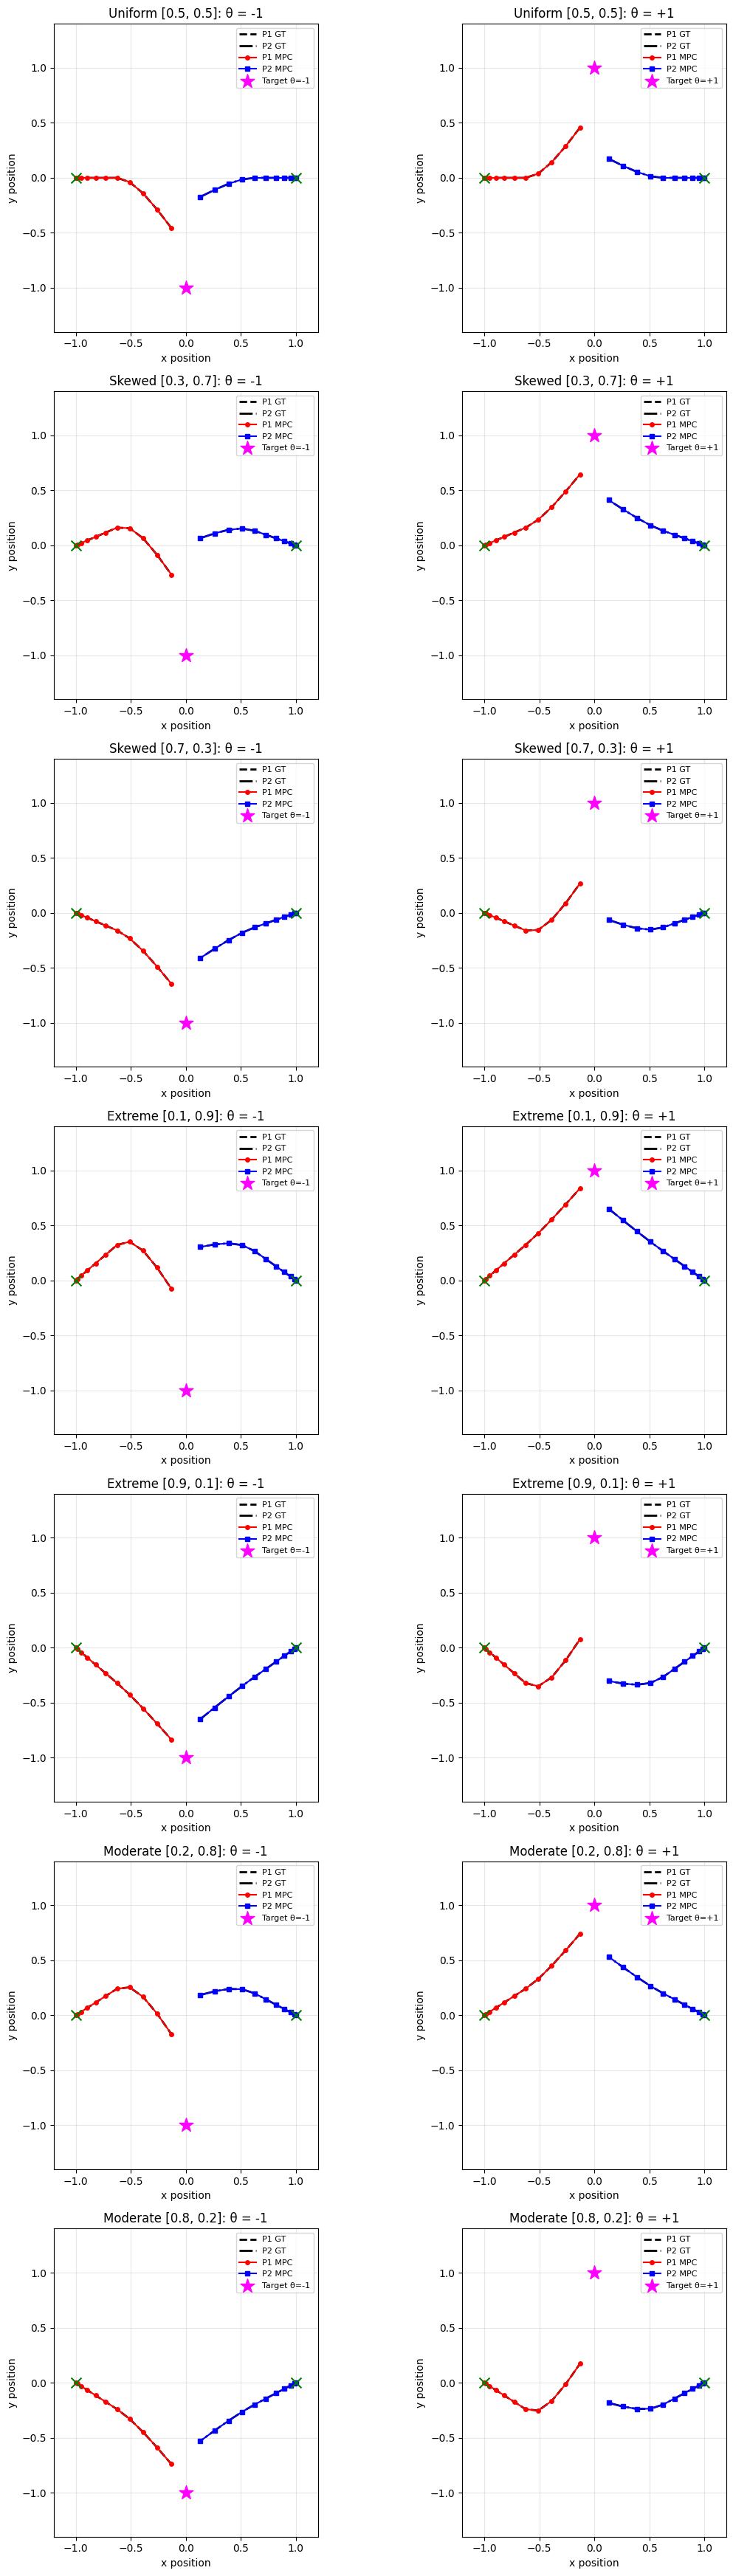

In [11]:
# Plot trajectories for each prior: P1 and P2 together on same plot
# Each row = one prior, each column = one type (θ=-1 or θ=+1)

num_priors = len(test_priors)
fig, axes = plt.subplots(num_priors, 2, figsize=(12, 5 * num_priors))

theta_vals = [-1.0, 1.0]

for row, (prior, prior_name) in enumerate(test_priors):
    for col, type_idx in enumerate([0, 1]):
        theta = theta_vals[type_idx]
        ax = axes[row, col] if num_priors > 1 else axes[col]
        
        # Get MPC results (4-tuple: x_traj, u_traj, v_traj, cost)
        x_mpc, u_mpc, v_mpc, cost_mpc = policy_results[(prior_name, type_idx)]
        gt, gt_cost = gt_results[(prior_name, type_idx)]
        
        # Extract positions
        # MPC: x_mpc is (K+1, 8) with [x1, x2] concatenated
        pos1_mpc = x_mpc[:, :2].detach().numpy()  # P1 position (x, y)
        pos2_mpc = x_mpc[:, 4:6].detach().numpy()  # P2 position (x, y)
        
        # GT positions
        pos1_gt = gt.x1_traj[:, :2].detach().numpy()
        pos2_gt = gt.x2_traj[:, :2].detach().numpy()
        
        # Plot ground truth (dashed lines)
        ax.plot(pos1_gt[:, 0], pos1_gt[:, 1], 'k--', linewidth=2, label='P1 GT')
        ax.plot(pos2_gt[:, 0], pos2_gt[:, 1], 'k-.', linewidth=2, label='P2 GT')
        
        # Plot MPC (solid lines with markers)
        ax.plot(pos1_mpc[:, 0], pos1_mpc[:, 1], 'r-o', markersize=4, linewidth=1.5, label='P1 MPC')
        ax.plot(pos2_mpc[:, 0], pos2_mpc[:, 1], 'b-s', markersize=4, linewidth=1.5, label='P2 MPC')
        
        # Start positions (green X)
        ax.scatter(pos1_mpc[0, 0], pos1_mpc[0, 1], c='green', marker='x', s=100, zorder=5)
        ax.scatter(pos2_mpc[0, 0], pos2_mpc[0, 1], c='green', marker='x', s=100, zorder=5)
        
        # Target (magenta star)
        target_y = theta
        ax.scatter(0.0, target_y, c='magenta', marker='*', s=200, label=f'Target θ={theta:+.0f}', zorder=5)
        
        # Formatting
        ax.set_xlim(-1.2, 1.2)
        ax.set_ylim(-1.4, 1.4)
        ax.set_aspect('equal')
        ax.set_xlabel('x position')
        ax.set_ylabel('y position')
        ax.set_title(f'{prior_name}: θ = {theta:+.0f}')
        ax.legend(loc='upper right', fontsize=8)
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('online_priors_trajectories.png', dpi=150)
plt.show()

## 8. Control Input Comparison

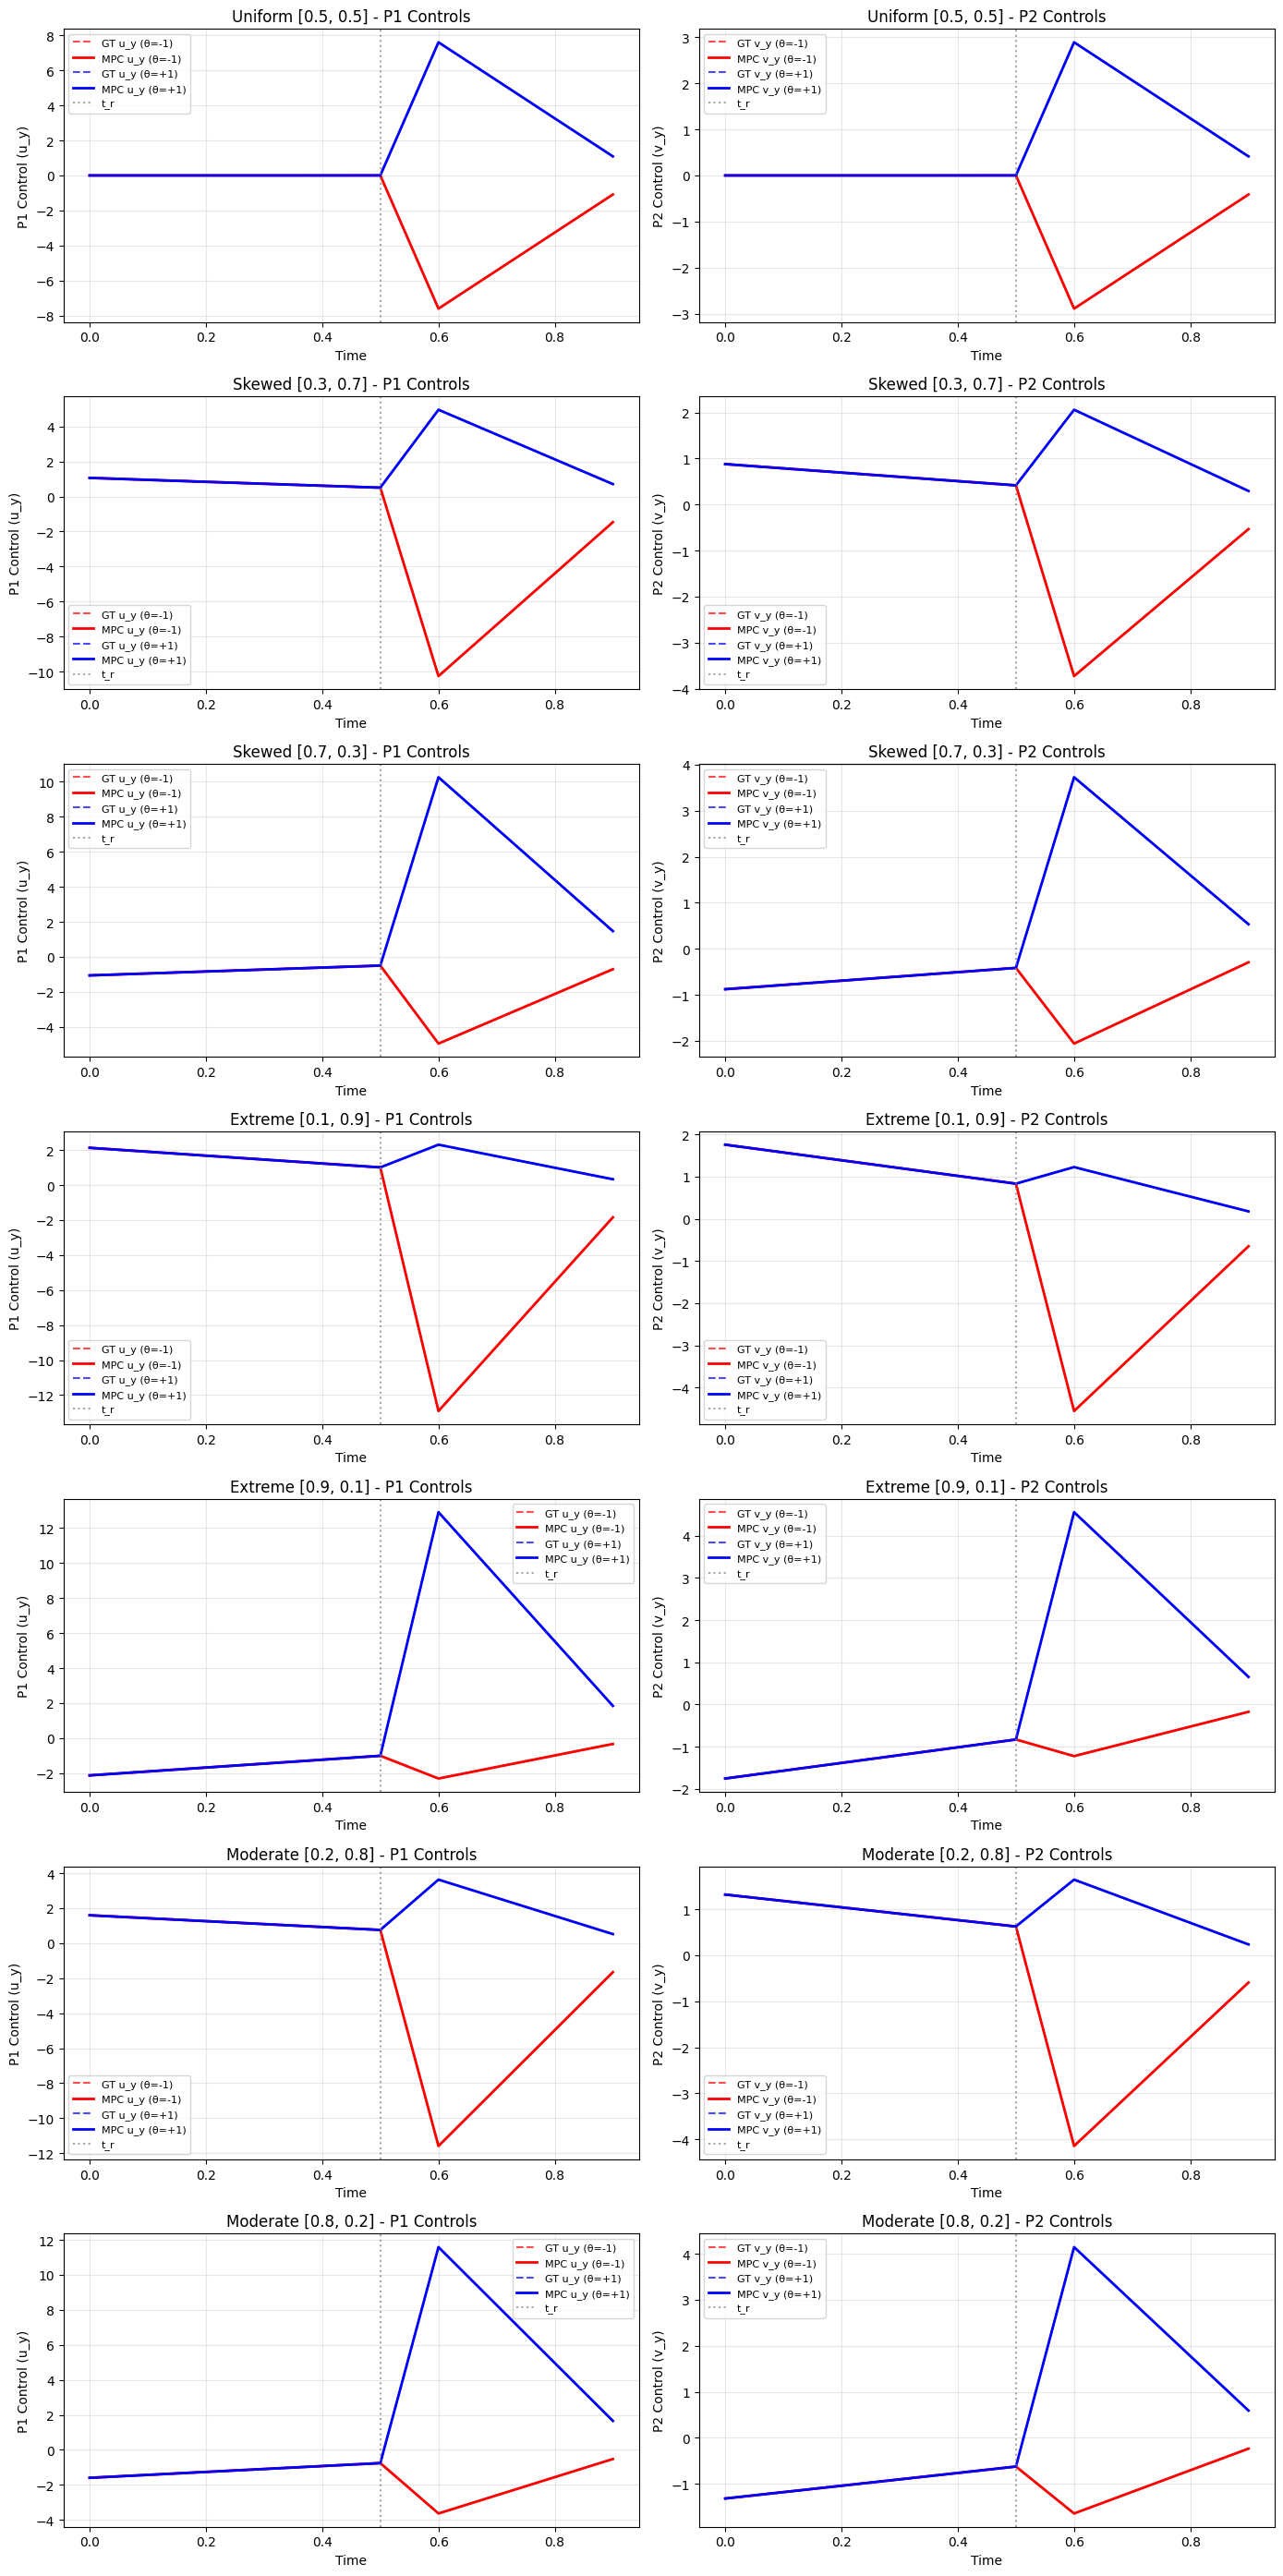

In [14]:
# Plot control inputs for each prior
# Each row = one prior, columns = P1 controls, P2 controls

t_ctrl = np.linspace(0, game_cfg.T - game_cfg.T/K, K)  # Control times

fig, axes = plt.subplots(len(test_priors), 2, figsize=(14, 4*len(test_priors)))

for row, (prior, prior_name) in enumerate(test_priors):
    # P1 controls
    ax1 = axes[row, 0] if len(test_priors) > 1 else axes[0]
    
    for type_idx in range(I):
        theta = theta_vals[type_idx]
        u_mpc = policy_results[(prior_name, type_idx)][1].detach().numpy()
        gt, _ = gt_results[(prior_name, type_idx)]
        u_gt = gt.u1_traj.detach().numpy()
        
        color = 'red' if type_idx == 0 else 'blue'
        label_suffix = f'θ={theta:+.0f}'
        
        # GT (dashed)
        ax1.plot(t_ctrl, u_gt[:, 1], f'{color[0]}--', alpha=0.7, linewidth=1.5, label=f'GT u_y ({label_suffix})')
        # MPC (solid)
        ax1.plot(t_ctrl, u_mpc[:, 1], f'{color[0]}-', linewidth=2, label=f'MPC u_y ({label_suffix})')
    
    ax1.axvline(0.5, color='gray', linestyle=':', alpha=0.7, label='t_r')
    ax1.set_xlabel('Time')
    ax1.set_ylabel('P1 Control (u_y)')
    ax1.set_title(f'{prior_name} - P1 Controls')
    ax1.legend(fontsize=8)
    ax1.grid(True, alpha=0.3)
    
    # P2 controls
    ax2 = axes[row, 1] if len(test_priors) > 1 else axes[1]
    
    for type_idx in range(I):
        theta = theta_vals[type_idx]
        v_mpc = policy_results[(prior_name, type_idx)][2].detach().numpy()
        gt, _ = gt_results[(prior_name, type_idx)]
        v_gt = gt.u2_traj.detach().numpy()
        
        color = 'red' if type_idx == 0 else 'blue'
        label_suffix = f'θ={theta:+.0f}'
        
        # GT (dashed)
        ax2.plot(t_ctrl, v_gt[:, 1], f'{color[0]}--', alpha=0.7, linewidth=1.5, label=f'GT v_y ({label_suffix})')
        # MPC (solid)
        ax2.plot(t_ctrl, v_mpc[:, 1], f'{color[0]}-', linewidth=2, label=f'MPC v_y ({label_suffix})')
    
    ax2.axvline(0.5, color='gray', linestyle=':', alpha=0.7, label='t_r')
    ax2.set_xlabel('Time')
    ax2.set_ylabel('P2 Control (v_y)')
    ax2.set_title(f'{prior_name} - P2 Controls')
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [16]:
# Compute errors for all priors and types
error_data = []

for prior, prior_name in test_priors:
    for type_idx in range(I):
        theta = theta_vals[type_idx]
        # 4-tuple: x_traj, u_traj, v_traj, cost
        x_mpc, u_mpc, v_mpc, cost_mpc = policy_results[(prior_name, type_idx)]
        gt, gt_cost = gt_results[(prior_name, type_idx)]
        
        # Extract positions
        x1_mpc = x_mpc[:, :4]
        x2_mpc = x_mpc[:, 4:]
        
        # Position errors
        pos1_err = (x1_mpc[-1, :2] - gt.x1_traj[-1, :2]).norm().item()
        pos2_err = (x2_mpc[-1, :2] - gt.x2_traj[-1, :2]).norm().item()
        
        # Cost error
        cost_err = abs(cost_mpc - gt_cost)
        
        error_data.append({
            'Prior': prior_name,
            'Type': f'θ={theta:+.0f}',
            'MPC Cost': cost_mpc,
            'GT Cost': gt_cost,
            'Cost Err': cost_err,
            'P1 Pos Err': pos1_err,
            'P2 Pos Err': pos2_err,
        })

df_errors = pd.DataFrame(error_data)

print("="*80)
print("ERROR SUMMARY: MPC vs Ground Truth")
print("="*80)
display(df_errors.round(4))

ERROR SUMMARY: MPC vs Ground Truth


,Prior,Type,MPC Cost,GT Cost,Cost Err,P1 Pos Err,P2 Pos Err
0,"Uniform [0.5, 0.5]",θ=-1,-0.2829,-0.2830,0.0,0.0001,0.0
1,"Uniform [0.5, 0.5]",θ=+1,-0.2830,-0.2830,0.0,0.0001,0.0
2,"Skewed [0.3, 0.7]",θ=-1,-0.3998,-0.3998,0.0,0.0001,0.0
3,"Skewed [0.3, 0.7]",θ=+1,-0.2051,-0.2051,0.0,0.0000,0.0
4,"Skewed [0.7, 0.3]",θ=-1,-0.2051,-0.2051,0.0,0.0000,0.0
5,"Skewed [0.7, 0.3]",θ=+1,-0.3998,-0.3998,0.0,0.0000,0.0
6,"Extreme [0.1, 0.9]",θ=-1,-0.5555,-0.5555,0.0,0.0001,0.0
7,"Extreme [0.1, 0.9]",θ=+1,-0.1662,-0.1662,0.0,0.0000,0.0
8,"Extreme [0.9, 0.1]",θ=-1,-0.1661,-0.1662,0.0,0.0000,0.0
9,"Extreme [0.9, 0.1]",θ=+1,-0.5556,-0.5555,0.0,0.0000,0.0
